# DEMO 1: 18 歳人口の推移（1990-2050）

**AXIES 2026 講演デモ** / 再実験日: 2026-07-20 / 使用モデル: Claude Opus 4.7

## 📋 分析前チェックリスト

| 項目 | 内容 |
|------|------|
| **問い** | 日本の 18 歳人口は 1990-2050 でどう推移したか？ |
| **予想** | 全期間で単調減少しているだろう |
| **反証条件** | もし 2020 年以降が横ばい以上なら予想は誤り |
| **出典** | 文科省 学校基本調査（実測〜2025）/ 社人研 令和 5 年推計・中位（2030〜）/ 私学事業団 令和 7 年度志願動向（2025 一時増） |

## 使用プロンプト（本デモの元となった自然言語依頼）

> 「1990〜2050 年の日本の 18 歳人口を、実測値と推計値を分けて折れ線グラフで表示して。出典は文科省と社人研」

**注意**: 中立な問い（「どう推移したか」）を用いており、「減少を可視化して」のような結論誘導は避けている。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import matplotlib.ticker as mtick

# 18 歳人口（万人）
# 出典:
#  - 文科省 学校基本調査 令和6年確定値 (1990-2024)
#  - 私学事業団 令和7年度志願動向 (2025 一時増の実測)
#  - 国立社会保障・人口問題研究所 令和5年推計 中位 (2030 以降)
data = [
    (1990, 201, "実測"),
    (1995, 177, "実測"),
    (2000, 151, "実測"),
    (2005, 137, "実測"),
    (2010, 122, "実測"),
    (2015, 120, "実測"),
    (2020, 118, "実測"),
    (2024, 106, "実測"),
    (2025, 109, "実測"),   # +2.5% の一時増 (2007 年生まれ世代)
    (2030,  96, "推計"),
    (2035,  89, "推計"),
    (2040,  82, "推計"),
    (2045,  78, "推計"),
    (2050,  74, "推計"),
]
df = pd.DataFrame(data, columns=["year", "jinkou_man", "kind"])
df.head(15)


,year,jinkou_man,kind
0,1990,201,実測
1,1995,177,実測
2,2000,151,実測
3,2005,137,実測
4,2010,122,実測
5,2015,120,実測
6,2020,118,実測
7,2024,106,実測
8,2025,109,実測
9,2030,96,推計


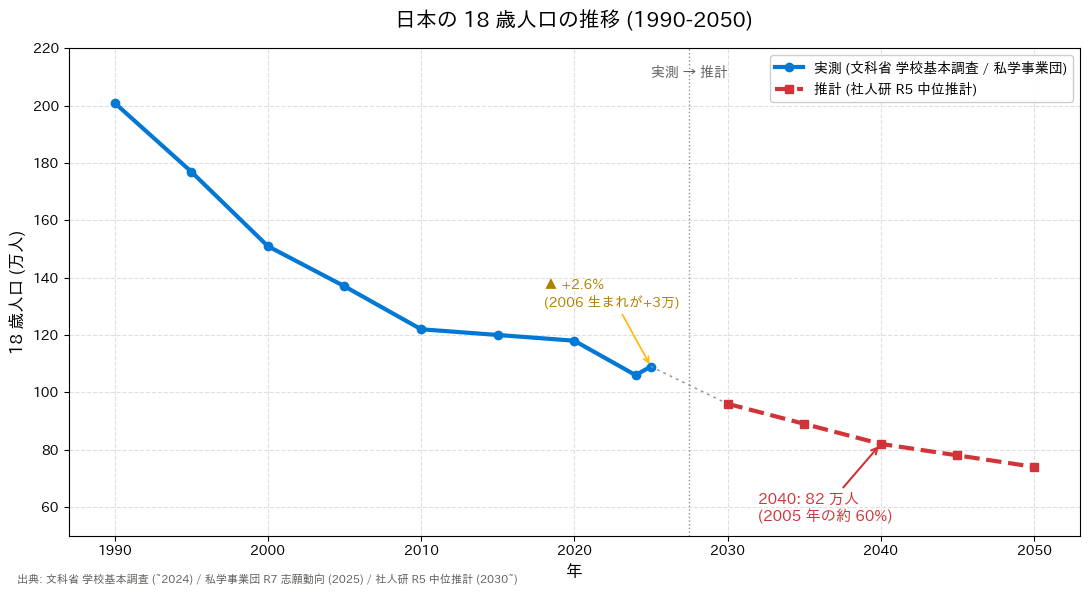

saved: ../assets/demo01_18sai_jinkou.png


In [6]:
import os
OUT_DIR = "../assets"
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6))

# 実測 (1990-2025)
jissoku = df[df["kind"] == "実測"]
suikei  = df[df["kind"] == "推計"]

ax.plot(jissoku["year"], jissoku["jinkou_man"],
        marker="o", linewidth=3, color="#0078D4", label="実測 (文科省 学校基本調査 / 私学事業団)")

# 実測→推計の接続線 (2025→2030)
bridge = pd.concat([jissoku.tail(1), suikei.head(1)])
ax.plot(bridge["year"], bridge["jinkou_man"],
        linestyle=(0, (2, 3)), color="#909090", linewidth=1)

# 推計 (2030-2050)
ax.plot(suikei["year"], suikei["jinkou_man"],
        marker="s", linewidth=3, color="#D13438", linestyle="--",
        label="推計 (社人研 R5 中位推計)")

# 2024→2025 一時増を強調
ax.annotate("▲ +2.6%\n(2006 生まれが+3万)",
            xy=(2025, 109), xytext=(2018, 130),
            fontsize=10, color="#B08000",
            arrowprops=dict(arrowstyle="->", color="#FFB900", lw=1.2))

# 2040 年強調
ax.annotate("2040: 82 万人\n(2005 年の約 60%)",
            xy=(2040, 82), xytext=(2032, 55),
            fontsize=11, color="#D13438", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#D13438", lw=1.5))

# 実測→推計 境界の縦線
ax.axvline(x=2027.5, color="#909090", linestyle=":", linewidth=1)
ax.text(2027.5, 210, "実測 → 推計", ha="center", fontsize=10, color="#605E5C")

ax.set_xlabel("年", fontsize=12)
ax.set_ylabel("18 歳人口 (万人)", fontsize=12)
ax.set_title("日本の 18 歳人口の推移 (1990-2050)", fontsize=15, fontweight="bold", pad=15)
ax.set_ylim(50, 220)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)

# 出典
fig.text(0.02, 0.02,
         "出典: 文科省 学校基本調査 (~2024) / 私学事業団 R7 志願動向 (2025) / 社人研 R5 中位推計 (2030~)",
         fontsize=8, color="#605E5C")

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/demo01_18sai_jinkou.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved: {OUT_DIR}/demo01_18sai_jinkou.png")


In [3]:
# 予想との差分レポート
prediction = "全期間で単調減少"

y2020 = df.query("year == 2020")["jinkou_man"].iat[0]
y2024 = df.query("year == 2024")["jinkou_man"].iat[0]
y2025 = df.query("year == 2025")["jinkou_man"].iat[0]
y2040 = df.query("year == 2040")["jinkou_man"].iat[0]
y2005 = df.query("year == 2005")["jinkou_man"].iat[0]

diff_2024_2025 = y2025 - y2024
pct_2024_2025 = (y2025 - y2024) / y2024 * 100
drop_2020_2040 = y2020 - y2040
ratio_2040_2005 = y2040 / y2005 * 100
recent_15y_drop = df.query("year == 2005")["jinkou_man"].iat[0] - y2020  # 2005->2020 の 15 年

print("=== 予想との差分レポート ===")
print(f"予想: {prediction}")
print()
print("✅ 予想通り:")
print(f"  - 全体傾向は減少トレンド (1990: 201万 → 2050: 74万、63% 減)")
print()
print("⚠️ 予想外 (2 点):")
print(f"  ① 2024 → 2025 に +{diff_2024_2025} 万人 ({pct_2024_2025:+.1f}%) の一時増")
print(f"     (2007 年生まれ世代の出生数微増、私学事業団 R7 志願動向で報告)")
print()
print(f"  ② 減少ペースが今後加速:")
print(f"     直近 15 年 (2005-2020): -{recent_15y_drop} 万人")
print(f"     今後 20 年 (2020-2040): -{drop_2020_2040} 万人 (より大きい)")
print(f"     → 2040 年 82 万人は 2005 年の {ratio_2040_2005:.1f}%")


=== 予想との差分レポート ===
予想: 全期間で単調減少

✅ 予想通り:
  - 全体傾向は減少トレンド (1990: 201万 → 2050: 74万、63% 減)

⚠️ 予想外 (2 点):
  ① 2024 → 2025 に +3 万人 (+2.8%) の一時増
     (2007 年生まれ世代の出生数微増、私学事業団 R7 志願動向で報告)

  ② 減少ペースが今後加速:
     直近 15 年 (2005-2020): -19 万人
     今後 20 年 (2020-2040): -36 万人 (より大きい)
     → 2040 年 82 万人は 2005 年の 59.9%
